In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("auto-mpg.csv")

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


In [4]:
df.shape

(398, 9)

In [5]:
df.columns

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model year', 'origin', 'car name'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    398 non-null    str    
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(3), int64(4), str(2)
memory usage: 28.1 KB


In [7]:
df.describe()

,mpg,cylinders,displacement,weight,acceleration,model year,origin
count,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000,398.000000
mean,23.514573,5.454774,193.425879,2970.424623,15.568090,76.010050,1.572864
std,7.815984,1.701004,104.269838,846.841774,2.757689,3.697627,0.802055
min,9.000000,3.000000,68.000000,1613.000000,8.000000,70.000000,1.000000
25%,17.500000,4.000000,104.250000,2223.750000,13.825000,73.000000,1.000000
50%,23.000000,4.000000,148.500000,2803.500000,15.500000,76.000000,1.000000
75%,29.000000,8.000000,262.000000,3608.000000,17.175000,79.000000,2.000000
max,46.600000,8.000000,455.000000,5140.000000,24.800000,82.000000,3.000000


In [8]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [9]:
df.replace('?', np.nan, inplace=True)

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
393,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
394,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
395,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
396,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


In [10]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [11]:
df['horsepower'] = pd.to_numeric(df['horsepower'])
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6124\2648492184.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


0      130.0
1      165.0
2      150.0
3      150.0
4      140.0
       ...  
393     86.0
394     52.0
395     84.0
396     79.0
397     82.0
Name: horsepower, Length: 398, dtype: float64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

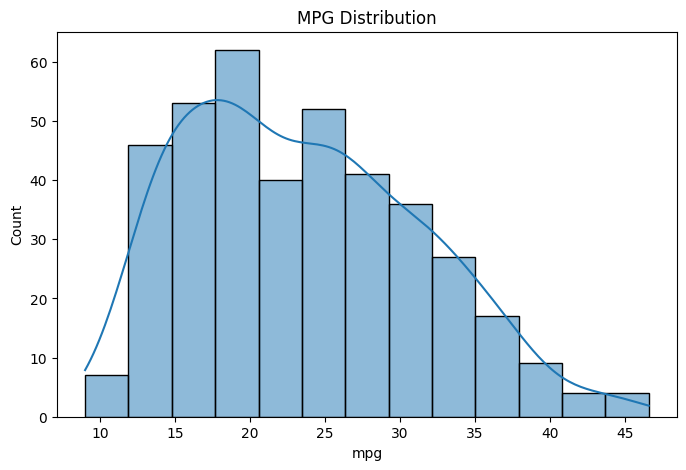

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df['mpg'], kde=True)

plt.title("MPG Distribution")
plt.show()

The MPG distribution is slightly right-skewed.
Most vehicles have MPG values between 15 and 30.
A few vehicles have very high MPG values, indicating possible outliers or highly fuel-efficient cars.
The target variable appears reasonably distributed for regression modeling.

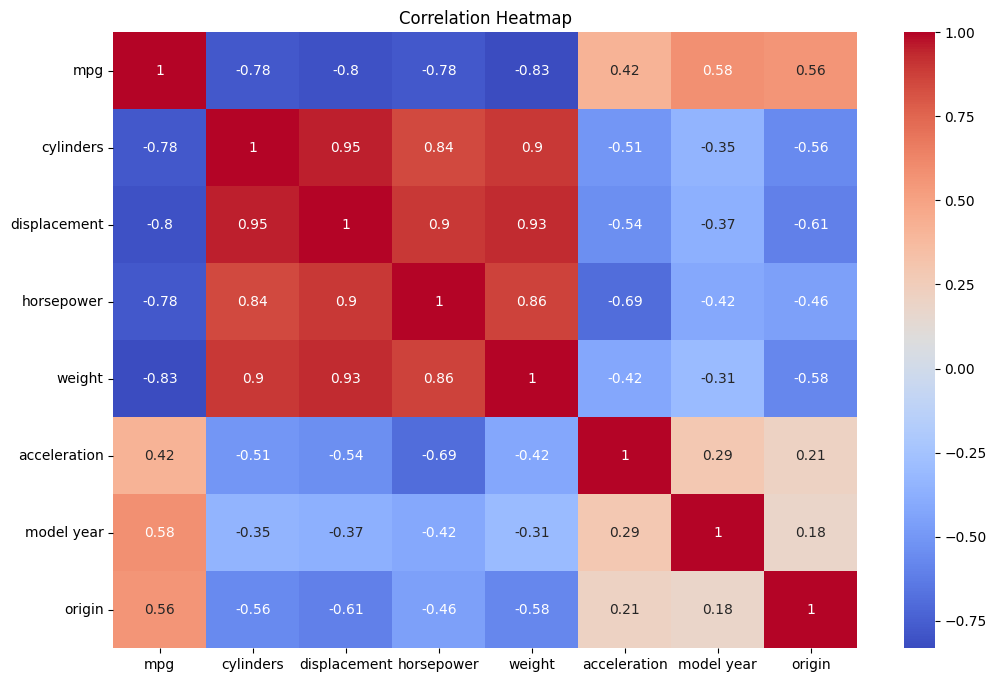

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

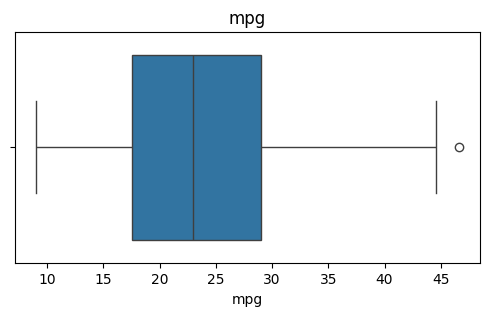

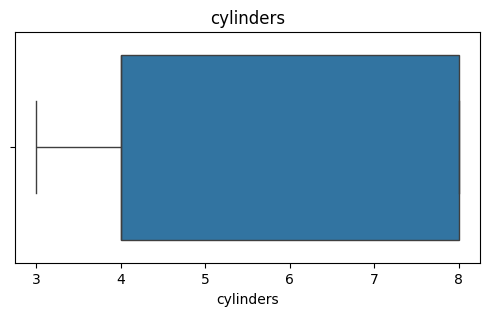

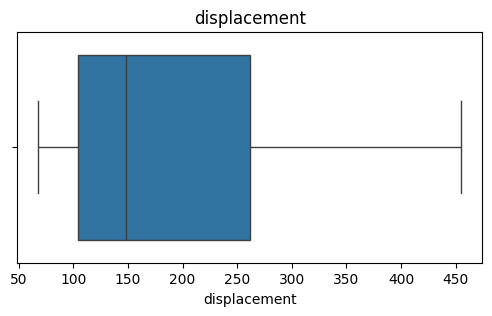

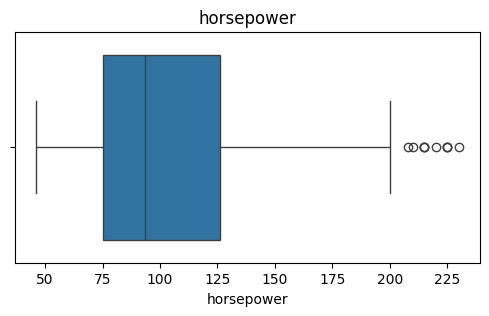

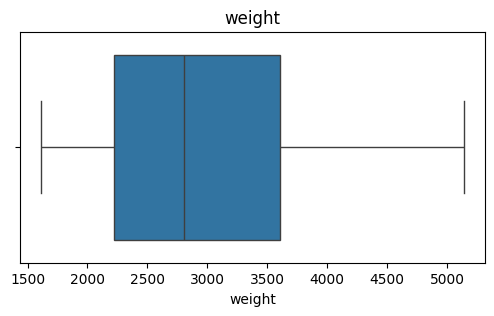

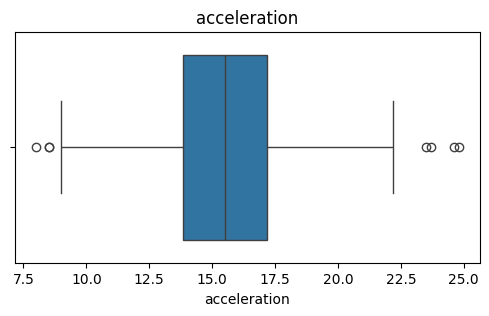

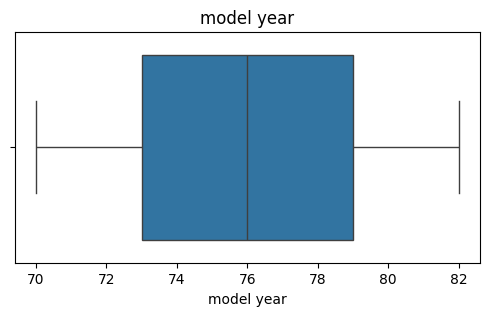

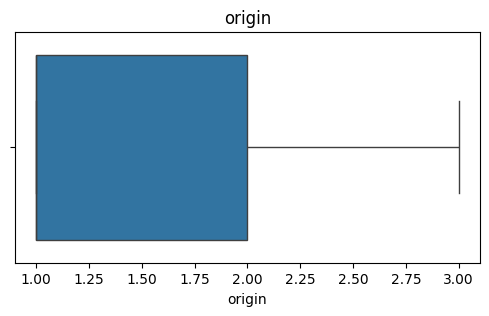

In [16]:
for column in df.select_dtypes(include=np.number):

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[column])

    plt.title(column)

    plt.show()

In [17]:
df['brand'] = df['car name'].apply(lambda x: x.split()[0])

In [18]:
df['brand'].value_counts()

brand
ford             51
chevrolet        43
plymouth         31
amc              28
dodge            28
toyota           25
datsun           23
buick            17
pontiac          16
volkswagen       15
honda            13
mercury          11
oldsmobile       10
mazda            10
peugeot           8
fiat              8
audi              7
chrysler          6
volvo             6
vw                6
renault           5
saab              4
opel              4
subaru            4
chevy             3
bmw               2
maxda             2
mercedes-benz     2
cadillac          2
hi                1
toyouta           1
chevroelt         1
capri             1
mercedes          1
vokswagen         1
triumph           1
nissan            1
Name: count, dtype: int64

In [19]:
df = pd.get_dummies(
    df,
    columns=['brand'],
    drop_first=True
)

In [20]:
df.drop('car name', axis=1, inplace=True)

In [21]:
df = pd.get_dummies(
    df,
    columns=['origin'],
    drop_first=True
)

In [22]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,brand_audi,brand_bmw,brand_buick,...,brand_subaru,brand_toyota,brand_toyouta,brand_triumph,brand_vokswagen,brand_volkswagen,brand_volvo,brand_vw,origin_2,origin_3
0,18.0,8,307.0,130.0,3504,12.0,70,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,15.0,8,350.0,165.0,3693,11.5,70,False,False,True,...,False,False,False,False,False,False,False,False,False,False
2,18.0,8,318.0,150.0,3436,11.0,70,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,16.0,8,304.0,150.0,3433,12.0,70,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,17.0,8,302.0,140.0,3449,10.5,70,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [23]:
df.rename(columns={'model year': 'model_year'}, inplace=True)

In [24]:
X = df.drop('mpg', axis=1)

y = df['mpg']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(318, 44)
(80, 44)
(318,)
(80,)


In [31]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Impute numeric missing values before scaling/modeling
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

In [32]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [33]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_mse = mean_squared_error(y_test, lr_pred)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_pred)

print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE :", lr_rmse)
print("R2 Score :", lr_r2)

MAE : 2.4552131483699298
MSE : 9.987246055444125
RMSE : 3.160260441078255
R2 Score : 0.8142475983369437


In [34]:
#ridge

from sklearn.linear_model import Ridge
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train_scaled, y_train)
ridge_pred = ridge_model.predict(X_test_scaled)
ridge_mae = mean_absolute_error(y_test, ridge_pred)

ridge_mse = mean_squared_error(y_test, ridge_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_pred)

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2 Score :", ridge_r2)

MAE : 2.454197108889793
MSE : 10.016217249488397
RMSE : 3.1648407937032785
R2 Score : 0.813708764223626


In [35]:
#svm
from sklearn.svm import SVR
svr_model = SVR(
    kernel='rbf'
)
svr_model.fit(X_train_scaled, y_train)
svr_pred = svr_model.predict(X_test_scaled)
svr_mae = mean_absolute_error(y_test, svr_pred)

svr_mse = mean_squared_error(y_test, svr_pred)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(y_test, svr_pred)

print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE :", svr_rmse)
print("R2 Score :", svr_r2)

MAE : 2.7510138490523675
MSE : 15.27804842195819
RMSE : 3.9087144206194178
R2 Score : 0.7158441705202385


In [36]:
#random forest regression

from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_mse = mean_squared_error(y_test, rf_pred)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_pred)

print("MAE :", rf_mae)
print("MSE :", rf_mse)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

MAE : 1.6248624999999994
MSE : 4.707445762499994
RMSE : 2.1696648963607243
R2 Score : 0.9124463990144411


In [37]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'SVR',
        'Random Forest'
    ],

    'R2 Score': [
        lr_r2,
        ridge_r2,
        svr_r2,
        rf_r2
    ],

    'RMSE': [
        lr_rmse,
        ridge_rmse,
        svr_rmse,
        rf_rmse
    ]
})

results

,Model,R2 Score,RMSE
0,Linear Regression,0.814248,3.160260
1,Ridge Regression,0.813709,3.164841
2,SVR,0.715844,3.908714
3,Random Forest,0.912446,2.169665


In [38]:
results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,R2 Score,RMSE
3,Random Forest,0.912446,2.169665
0,Linear Regression,0.814248,3.160260
1,Ridge Regression,0.813709,3.164841
2,SVR,0.715844,3.908714


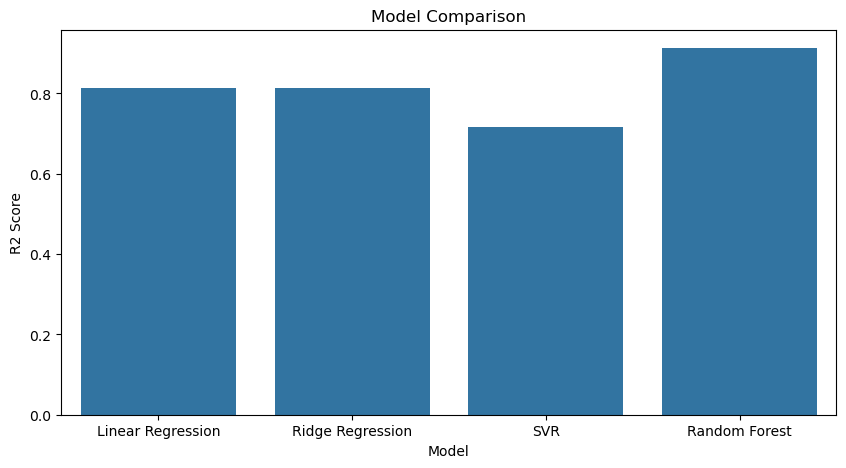

In [84]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='R2 Score',
    data=results
)

plt.title("Model Comparison")

plt.show()

In [39]:
#hyperperameter tuning
from sklearn.model_selection import GridSearchCV
param_grid = {

    'n_estimators': [50, 100, 200],

    'max_depth': [5, 10, 15],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]
}
rf = RandomForestRegressor(
    random_state=42
)
grid_search = GridSearchCV(

    estimator=rf,

    param_grid=param_grid,

    cv=5,

    scoring='r2',

    n_jobs=-1,

    verbose=2
)
grid_search.fit(X_train_scaled, y_train)
grid_search.best_params_
grid_search.best_score_
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test_scaled)
final_r2 = r2_score(y_test, best_pred)

final_rmse = np.sqrt(
    mean_squared_error(y_test, best_pred)
)

print("Final R2 Score:", final_r2)

print("Final RMSE:", final_rmse)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Final R2 Score: 0.9128963580473113
Final RMSE: 2.164082499691122


In [40]:
grid_search.best_params_
grid_search.best_score_
best_rf = grid_search.best_estimator_
best_pred = best_rf.predict(X_test_scaled)
final_r2 = r2_score(y_test, best_pred)

print(final_r2)

0.9128963580473113


In [41]:
grid_search.best_params_

{'max_depth': 10,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 50}

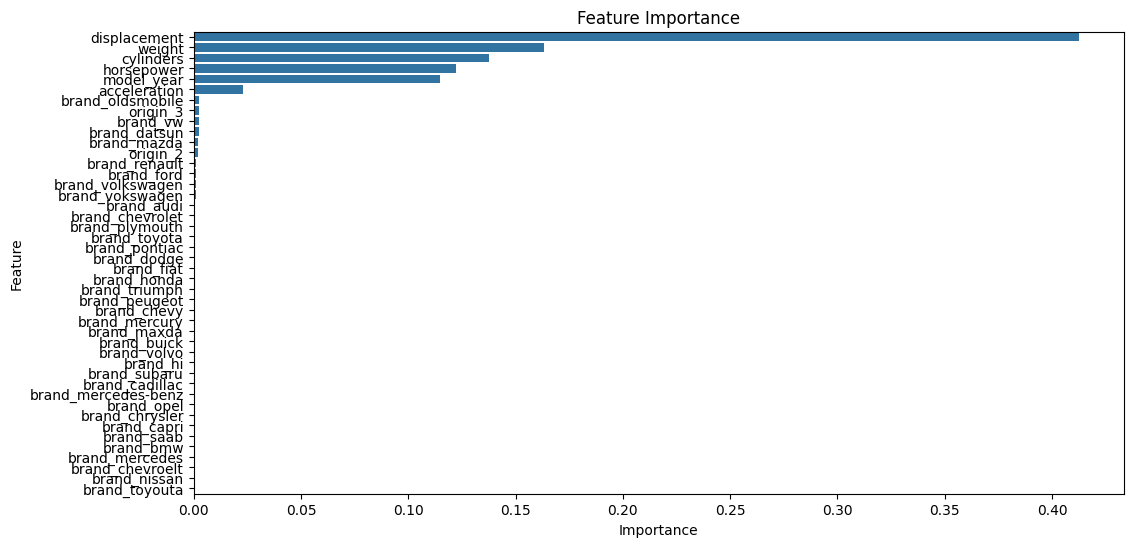

In [42]:
##Feature Importance

importance = best_rf.feature_importances_
feature_importance = pd.DataFrame({

    'Feature': X.columns,

    'Importance': importance

})
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance


plt.figure(figsize=(12,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")

plt.show()

Weight and horsepower were the most influential features in predicting MPG.
Heavier cars generally showed lower fuel efficiency.

In [43]:
## pipelinea

from sklearn.pipeline import Pipeline
final_pipeline = Pipeline([

    ('scaler', StandardScaler()),

    ('model', RandomForestRegressor(

        max_depth=15,

        min_samples_leaf=1,

        min_samples_split=2,

        n_estimators=50,

        random_state=42
    ))
])

final_pipeline.fit(X_train, y_train)
pipeline_pred = final_pipeline.predict(X_test)
pipeline_r2 = r2_score(y_test, pipeline_pred)

print("Pipeline R2 Score:", pipeline_r2)

Pipeline R2 Score: 0.9074662451558257


In [44]:
import joblib

joblib.dump(final_pipeline, 'final_pipeline.pkl')

['final_pipeline.pkl']